In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def f(x):
    return 3 * x**2 - 4 * x + 5

In [ ]:
f(3.0)

20.0

In [12]:
xs = np.arange(-5, 5, 0.25)
print(xs)
ys = f(xs)
ys

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]


array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

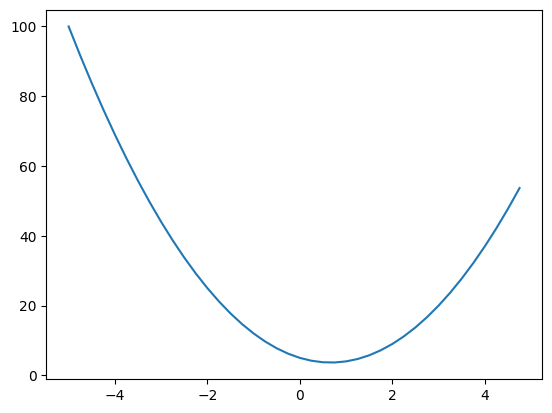

In [13]:
plt.plot(xs, ys)
plt.show()

In [3]:
from micro_grad.engine import Value

# case 1: basic add and multiply
# f = a * b + c
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
f = a * b + c
f.backward()
print("case 1: f = a * b + c")
print(f"  f    = {f.data}")  # 2*-3 + 10 = 4
print(f"  df/da = {a.grad}")  # b = -3
print(f"  df/db = {b.grad}")  # a = 2
print(f"  df/dc = {c.grad}")  # 1
print()

# case 2: power and division
# g = x**2 / y
x = Value(3.0)
y = Value(4.0)
g = x**2 / y
g.backward()
print("case 2: g = x**2 / y")
print(f"  g     = {g.data}")  # 9/4 = 2.25
print(f"  dg/dx = {x.grad}")  # 2x/y = 6/4 = 1.5
print(f"  dg/dy = {y.grad}")  # -x**2/y**2 = -9/16 = -0.5625
print()

# case 3: reused variable (gradient accumulates)
# h = q + q * q
q = Value(5.0)
h = q + q * q
h.backward()
print("case 3: h = q + q * q")
print(f"  h     = {h.data}")  # 5 + 25 = 30
print(f"  dh/dq = {q.grad}")  # 1 + 2q = 11
print()

# case 4: subtraction, negation and right-hand operators
# k = 2 - n + 3 * n
n = Value(7.0)
k = 2 - n + 3 * n
k.backward()
print("case 4: k = 2 - n + 3 * n")
print(f"  k     = {k.data}")  # 2 - 7 + 21 = 16
print(f"  dk/dn = {n.grad}")  # -1 + 3 = 2
print()

# case 5: small expression graph
# L = (a1 * w1 + a2 * w2 + bias)
a1, a2 = Value(1.0), Value(-2.0)
w1, w2 = Value(3.0), Value(4.0)
bias = Value(0.5)
L = a1 * w1 + a2 * w2 + bias
L.backward()
print("case 5: L = a1*w1 + a2*w2 + bias")
print(f"  L      = {L.data}")  # 3 - 8 + 0.5 = -4.5
print(f"  dL/dw1 = {w1.grad}")  # a1 = 1
print(f"  dL/dw2 = {w2.grad}")  # a2 = -2
print(f"  dL/da1 = {a1.grad}")  # w1 = 3

case 1: f = a * b + c
  f    = 4.0
  df/da = -3.0
  df/db = 2.0
  df/dc = 1.0

case 2: g = x**2 / y
  g     = 2.25
  dg/dx = 1.5
  dg/dy = -0.5625

case 3: h = q + q * q
  h     = 30.0
  dh/dq = 11.0

case 4: k = 2 - n + 3 * n
  k     = 16.0
  dk/dn = 2.0

case 5: L = a1*w1 + a2*w2 + bias
  L      = -4.5
  dL/dw1 = 1.0
  dL/dw2 = -2.0
  dL/da1 = 3.0


In [4]:
from micro_grad.nn import Neuron, Layer, MLP

x = [2.0, 3.0, -1.0]
neuron = Neuron(len(x))

print(f"Neuron output: {neuron(x)}")  # Print the output value

layer = Layer(3, 4)
print(f"Layer outputs: {layer(x)}")

mlp = MLP(3, [4, 4, 1])
print(f"MLP outputs: {mlp(x)}")

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # Ground truth labels for the inputs

# y_pred = [
#     mlp(x) for x in xs
# ]  # Calculate the predicted outputs for each input in xs
# print(f"Predicted outputs: {y_pred}")
# loss = sum((yout - ygt) ** 2 for yout, ygt in zip(y_pred, ys))
# print(f"Loss: {loss}")
# loss.backward()

for k in range(20):
    y_pred = [
        mlp(x) for x in xs
    ]  # Calculate the predicted outputs for each input in xs
    loss = sum((yout - ygt) ** 2 for yout, ygt in zip(y_pred, ys))

    for p in mlp.parameters():
        p.grad = 0.0  # Reset gradients before backward pass
    loss.backward()

    for p in mlp.parameters():
        p.data -= 0.01 * p.grad  # Update the parameters using gradient descent

    print(f"Step {k}, Loss: {loss.data}")

Neuron output: Value(data=0.9994428628071302, grad=0.0)
Layer outputs: [Value(data=-0.660376388457115, grad=0.0), Value(data=-0.9347295657768189, grad=0.0), Value(data=-0.9999786857954996, grad=0.0), Value(data=0.9788407282453444, grad=0.0)]
MLP outputs: Value(data=-0.28635924033149707, grad=0.0)
Step 0, Loss: 6.521367040053819
Step 1, Loss: 5.703432371950081
Step 2, Loss: 5.220756210149079
Step 3, Loss: 4.958244029421601
Step 4, Loss: 4.7832541733981335
Step 5, Loss: 4.638682423449929
Step 6, Loss: 4.503819368471501
Step 7, Loss: 4.370697733931176
Step 8, Loss: 4.235749753773284
Step 9, Loss: 4.096975549835413
Step 10, Loss: 3.9529736725593447
Step 11, Loss: 3.8026432480544923
Step 12, Loss: 3.6451513023827085
Step 13, Loss: 3.480016832571485
Step 14, Loss: 3.3072494641884913
Step 15, Loss: 3.1274996786695413
Step 16, Loss: 2.9421675162320806
Step 17, Loss: 2.753405892519358
Step 18, Loss: 2.5639715237522807
Step 19, Loss: 2.3769313134390666
